In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shubhi13/dailydelhiclimatetest/DailyDelhiClimateTrain.csv
/kaggle/input/datasets/shubhi13/dailydelhiclimatetest/DailyDelhiClimateTest.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("/kaggle/input/datasets/shubhi13/dailydelhiclimatetest/DailyDelhiClimateTrain.csv")

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [8]:
df = df.drop(['humidity','wind_speed','meanpressure'], axis = 1)

In [9]:
df.head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


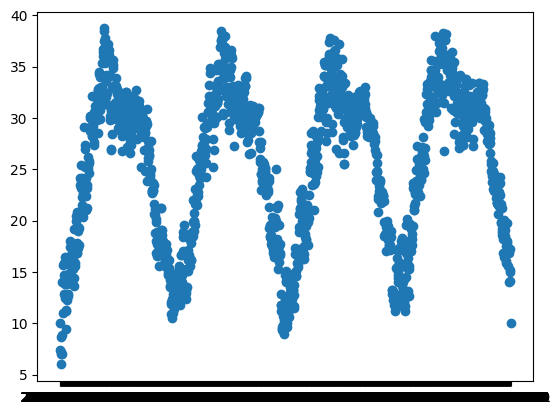

In [13]:
import matplotlib.pyplot as plt
plt.scatter(df['date'],df['meantemp'])

In [14]:
x1 = df['meantemp'].ewm(alpha=0.9).mean()

In [15]:
x1

0       10.000000
1        7.636364
2        7.213213
3        8.521452
4        6.252123
          ...    
1457    17.180754
1458    15.432361
1459    14.228950
1460    14.970263
1461    10.497026
Name: meantemp, Length: 1462, dtype: float64

In [16]:
df['ewma'] = x1
df

,date,meantemp,ewma
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,7.636364
2,2013-01-03,7.166667,7.213213
3,2013-01-04,8.666667,8.521452
4,2013-01-05,6.000000,6.252123
...,...,...,...
1457,2016-12-28,17.217391,17.180754
1458,2016-12-29,15.238095,15.432361
1459,2016-12-30,14.095238,14.228950
1460,2016-12-31,15.052632,14.970263


(1095.0, 1276.0)

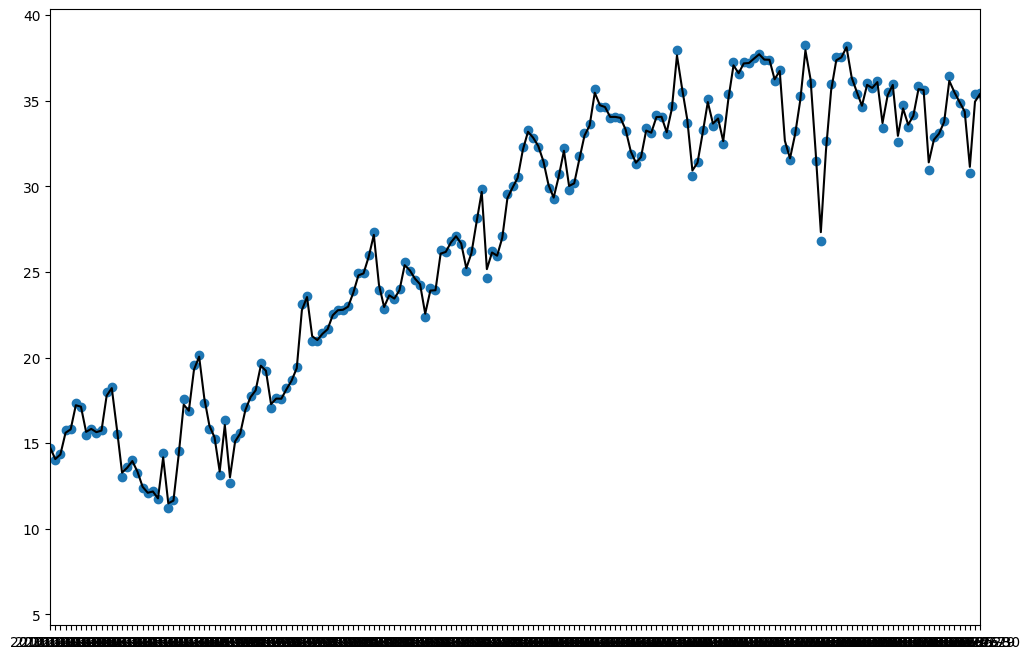

In [26]:
plt.figure(figsize=(12,8))
plt.scatter(df['date'],df['meantemp'])
plt.plot(df['date'],x1, color = 'black')
plt.xlim('2016-01-01', '2016-06-30') 